# 6 — Material para o artigo: a matriz de conexão J

Notebook dedicado ao que vai para o artigo — separado do `2-rede-antenas` (narrativa completa da
construção da rede) e do `5-exploracao` (bancada de testes). Aqui o objetivo é isolar **um**
resultado por vez, explicado do zero, pronto para virar figura e texto.

Primeiro assunto: a **matriz de conexão J**, na formulação de
*Detecting Communities from Cell Phone Antennas*. Em vez de chamar a função pronta direto, o
cálculo é refeito passo a passo abaixo — para deixar explícito exatamente onde e como cada peça
(K, o denominador, J) é montada — e só depois conferido contra `src/antenna.py`, que é a versão
testada usada pelo pipeline.

## 1. Preparação

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from networkx.algorithms.community import louvain_communities, modularity

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 40)

from src.utils import load_config
from src import antenna
from src.graph_builder import build_edges_graph, build_user_antenna_map

CIDADE = "campinas"
config = load_config(CIDADE)

edges_antenna = pd.read_parquet(ROOT / config["data"]["edges_antenna_path"])
antennas = pd.read_parquet(ROOT / config["data"]["antennas_path"])

net = antenna.build(edges_antenna, antennas, config)
nodes = net.nodes   # uma linha por região (antena)
G = net.G           # grafo não-direcionado ponderado

print(f"{len(nodes)} regiões | {G.number_of_edges():,} fluxos | {nodes['n_users'].sum():,} moradores")

145 regiões | 5,817 fluxos | 25,176 moradores


## 2. De chamada para contato — o que é k_i(l)

O paper define, para cada indivíduo *i*, a quantidade `k_i(l)`: **quantos contatos distintos** a
pessoa *i* tem entre os moradores da antena *l*. Duas coisas importantes nessa definição:

- **É contato, não chamada.** Duas pessoas que se telefonam 200 vezes contam como **1** contato,
  não 200. O que importa é se existe ou não um laço entre elas.
- **É repartido por antena.** Os contatos de *i* são espalhados entre as regiões onde os outros
  moram — por isso `k_i(l)`, e não só `k_i`.

O primeiro passo, então, é reduzir a base de chamadas (que tem uma linha por par emissor→receptor,
possivelmente repetida nos dois sentidos) a **um par por contato**.

In [2]:
# um registro por par de usuários que já se falaram, sem repetir A→B e B→A
pares = build_edges_graph(edges_antenna)[["source", "target"]]
pares = pares[pares["source"] != pares["target"]]   # autochamada é artefato do dado

# antena de residência de cada usuário
user_antenna = build_user_antenna_map(edges_antenna)

print(f"{len(pares):,} pares (contatos) distintos de usuários")
print(f"{len(user_antenna):,} usuários com antena residencial conhecida")

31,488 pares (contatos) distintos de usuários
25,176 usuários com antena residencial conhecida


Um exemplo concreto — os contatos de um único usuário, repartidos por antena (isso é `k_i(l)` para um `i`):

In [3]:
i = pares["source"].iloc[0]
contatos_de_i = pd.concat([
    pares.loc[pares["source"] == i, "target"],
    pares.loc[pares["target"] == i, "source"],
])
k_i_por_antena = contatos_de_i.map(user_antenna).value_counts()

print(f"usuário {i}: {len(contatos_de_i)} contatos distintos, espalhados por {k_i_por_antena.size} antenas")
k_i_por_antena.head(10).rename("k_i(l)").to_frame()

usuário 0001AC47949837E4419D616DC111DCCE: 2 contatos distintos, espalhados por 2 antenas


,k_i(l)
8362,1
22,1


## 3. K_lm — somando k_i(l) por região (o numerador)

    K_lm = Σ_{i ∈ V_l} k_i(m)

Ou seja: soma, sobre **todos** os moradores de *l*, quantos contatos cada um tem em *m*. Fazemos
isso de uma vez para todas as regiões com um `crosstab`: mapeamos os dois lados de cada par para a
antena de residência e contamos quantos pares caem em cada combinação (antena_a, antena_b).

Essa contagem crua ainda não é K. Cada par conectado `(i ∈ l, j ∈ m)` é visto de **dois** ângulos —
uma vez como o contato de *i* em *m*, outra vez como o contato de *j* em *l*. Por isso a soma da
matriz com sua transposta: para `l ≠ m`, soma a contagem nas duas direções `(l, m)` e `(m, l)`.

In [4]:
antenas_idx = pd.Index(nodes["antenna_id"], name="antenna_id")

antena_a = pares["source"].map(user_antenna)
antena_b = pares["target"].map(user_antenna)

# contagem bruta: quantos pares caem em cada combinação (antena_a, antena_b)
# usuários sem antena conhecida (NaN) são descartados automaticamente pelo crosstab
contagem = pd.crosstab(antena_a, antena_b).reindex(index=antenas_idx, columns=antenas_idx, fill_value=0)

# K_lm = contagem(l,m) + contagem(m,l) — cada par conectado entra pelos seus dois extremos
K = pd.DataFrame(
    contagem.to_numpy() + contagem.to_numpy().T,
    index=antenas_idx, columns=antenas_idx,
)

print(f"K é simétrica: {np.allclose(K.to_numpy(), K.to_numpy().T)}")
print(f"soma de K fora da diagonal / 2 = {(K.to_numpy()[~np.eye(len(K), dtype=bool)].sum() // 2):,} contatos entre regiões distintas")
K.iloc[:6, :6]

K é simétrica: True
soma de K fora da diagonal / 2 = 23,016 contatos entre regiões distintas


antenna_id,22,52,275,312,321,331
antenna_id,,,,,,
22,88,2,1,6,3,2
52,2,40,0,3,2,1
275,1,0,78,4,1,0
312,6,3,4,184,4,1
321,3,2,1,4,136,4
331,2,1,0,1,4,46


**A diagonal fica de fora daqui.** `K_ll` conta contatos *dentro* da mesma região, e o denominador
correto para ela não é `u_l · u_l` (ver docstring de `build_contact_matrix` para as três
convenções). Como o objetivo desta seção é o mapa de calor **entre** regiões, zeramos a diagonal —
convenção `"zero"` da função — e a insularidade (chamadas internas) já foi tratada à parte na
construção dos nós.

In [5]:
K_arr = K.to_numpy().copy()
np.fill_diagonal(K_arr, 0)
K_entre_regioes = pd.DataFrame(K_arr, index=antenas_idx, columns=antenas_idx)

## 4. u_l — moradores por região (o denominador)

    J_lm = K_lm / (u_l · u_m)

`u_l · u_m` é o número de **pares possíveis** entre os moradores de *l* e os de *m* — o
denominador que transforma um número absoluto de contatos numa fração em [0, 1].

In [6]:
u = nodes.set_index("antenna_id")["n_users"].reindex(antenas_idx).to_numpy(dtype=float)
denominador = pd.DataFrame(np.outer(u, u), index=antenas_idx, columns=antenas_idx)

fora_diag = ~np.eye(len(denominador), dtype=bool)
print(f"pares possíveis entre duas regiões: mín {denominador.to_numpy()[fora_diag].min():,.0f}, "
      f"máx {denominador.to_numpy()[fora_diag].max():,.0f}")

pares possíveis entre duas regiões: mín 143, máx 309,936


## 5. J_lm — a intensidade normalizada

Agora é só dividir. `J` vive em [0, 1]: é a **fração** dos pares possíveis entre duas regiões que
de fato existe como contato.

In [7]:
with np.errstate(divide="ignore", invalid="ignore"):
    J = pd.DataFrame(
        np.where(denominador.to_numpy() > 0, K_entre_regioes.to_numpy() / denominador.to_numpy(), np.nan),
        index=antenas_idx, columns=antenas_idx,
    )

vals = J.to_numpy()[np.triu_indices(len(J), k=1)]
pos = vals[vals > 0]

print(f"pares de regiões conectados: {len(pos):,} de {len(vals):,} possíveis ({len(pos)/len(vals):.1%})")
print(f"J entre pares conectados: mediana {np.median(pos):.2e} | máximo {pos.max():.2e}")

pares de regiões conectados: 5,817 de 10,440 possíveis (55.7%)
J entre pares conectados: mediana 7.69e-05 | máximo 4.96e-03


### Conferência contra `src/antenna.py`

O cálculo acima foi refeito do zero só para deixar cada peça explícita. `build_contact_matrix` é a
versão testada e usada pelo pipeline — as duas precisam bater exatamente.

In [8]:
cm = antenna.build_contact_matrix(edges_antenna, nodes, diagonal="zero")
cm_K = cm.K.reindex(index=antenas_idx, columns=antenas_idx)
cm_J = cm.J.reindex(index=antenas_idx, columns=antenas_idx)

print("K bate com build_contact_matrix:", np.array_equal(K_entre_regioes.to_numpy(), cm_K.to_numpy()))
print("J bate com build_contact_matrix:",
      np.allclose(J.fillna(-1).to_numpy(), cm_J.fillna(-1).to_numpy()))

K bate com build_contact_matrix: True
J bate com build_contact_matrix: True


## 6. Ordenando pelas macro-regiões

Para o mapa de calor fazer sentido visualmente, agrupamos as antenas pelas macro-regiões
funcionais (Louvain ponderado sobre os fluxos) — a mesma divisão usada no resto do projeto. Se a
divisão for real, os blocos na diagonal devem ficar mais densos que o resto.

In [9]:
comunidades = louvain_communities(G, weight="weight", seed=42)
macro = pd.Series({a: i for i, c in enumerate(comunidades) for a in c}, name="macro_region")

nodes_ordenado = nodes.assign(macro_region=nodes["antenna_id"].map(macro)) \
    .sort_values(["macro_region", "antenna_id"])
ordem = nodes_ordenado["antenna_id"].to_numpy()
cortes = np.cumsum(nodes_ordenado["macro_region"].value_counts().sort_index().to_numpy())[:-1]

print(f"{len(comunidades)} macro-regiões | modularidade {modularity(G, comunidades, weight='weight'):.3f}")

5 macro-regiões | modularidade 0.404


## 7. O mapa de calor de J

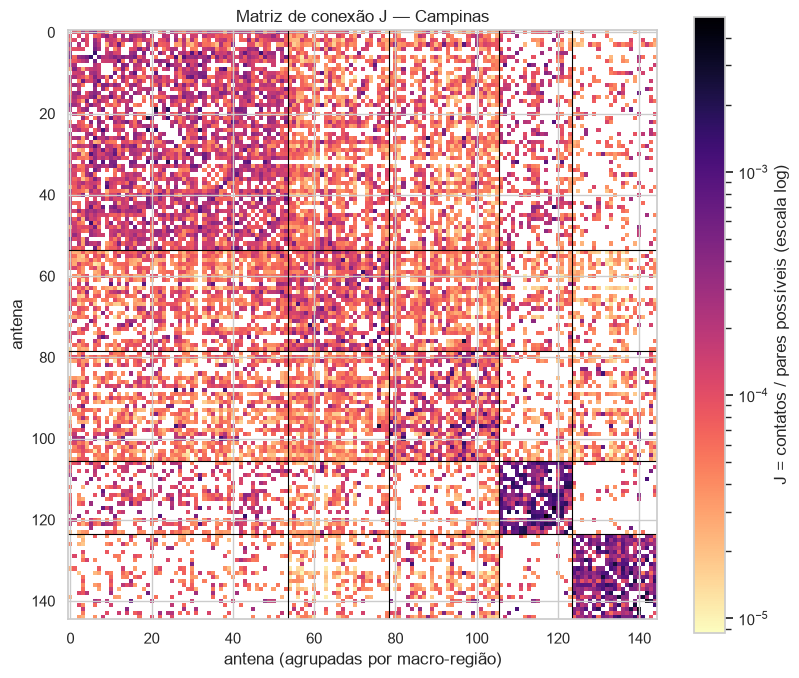

J médio dentro da mesma macro-região: 2.18e-04
J médio entre macro-regiões distintas: 4.39e-05
razão: 5.0x


In [10]:
Jm = J.reindex(index=ordem, columns=ordem).to_numpy()
positivos = Jm[Jm > 0]

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(
    np.where(Jm > 0, Jm, np.nan), cmap="magma_r",
    norm=LogNorm(vmin=positivos.min(), vmax=positivos.max()),
    interpolation="nearest",
)
fig.colorbar(im, ax=ax, label="J = contatos / pares possíveis (escala log)")
for c in cortes:
    ax.axhline(c - 0.5, color="black", lw=0.8)
    ax.axvline(c - 0.5, color="black", lw=0.8)
ax.set_xlabel("antena (agrupadas por macro-região)")
ax.set_ylabel("antena")
ax.set_title(f"Matriz de conexão J — {config['city_name']}")
plt.show()

mr = macro.reindex(ordem).to_numpy()
mesma = (mr[:, None] == mr[None, :]) & ~np.eye(len(Jm), dtype=bool)
fora = ~np.eye(len(Jm), dtype=bool)

print(f"J médio dentro da mesma macro-região: {Jm[mesma].mean():.2e}")
print(f"J médio entre macro-regiões distintas: {Jm[fora & ~mesma].mean():.2e}")
print(f"razão: {Jm[mesma].mean() / Jm[fora & ~mesma].mean():.1f}x")

### Como ler

Os blocos na diagonal — cada um correspondendo a uma macro-região — ficam visivelmente mais
escuros (J mais alto) do que o resto da matriz. Isso é o teste de consistência entre dois métodos
independentes: o Louvain nunca vê a matriz `J` (ele otimiza modularidade sobre o volume bruto de
chamadas), e ainda assim as regiões que ele agrupou são também as mais densamente conectadas em
`J`, a métrica normalizada por tamanho.